In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn import datasets
%matplotlib inline
from sklearn.cluster import KMeans
from matplotlib import style
from scipy.cluster.hierarchy import dendrogram, linkage
style.use('ggplot')
from sklearn import preprocessing
import math

In [3]:
# ─────────────────────────────────────────────────────────────────────────
# DATA LOADING — SECURE VERSION
# ─────────────────────────────────────────────────────────────────────────
# The raw dataset (UserPerception.xlsx) is NOT included in this repository
# to protect respondent privacy and comply with GDPR.
#
# To run this notebook you must supply your own copy of the data file.
# Place it in one of the two locations described below.
# ─────────────────────────────────────────────────────────────────────────

import os
import sys

DATA_FILE = 'UserPerception.xlsx'   # <-- change filename here if yours differs

# ── Option A: Google Colab  ───────────────────────────────────────────────
# Upload the file to YOUR OWN Google Drive and authenticate below.
# This notebook never accesses anyone else's Drive.
COLAB_PATH = f'/content/drive/MyDrive/{DATA_FILE}'   # adjust subfolder if needed

# ── Option B: Local Jupyter  ──────────────────────────────────────────────
# Place the file in a folder called 'data/' next to this notebook.
LOCAL_PATH = os.path.join('data', DATA_FILE)

# ── Auto-detect environment and locate the file ───────────────────────────
file_path = None

try:
    import google.colab          # only succeeds inside Colab
    from google.colab import drive
    drive.mount('/content/drive')
    if os.path.exists(COLAB_PATH):
        file_path = COLAB_PATH
        print(f'Running in Colab  —  file found at: {COLAB_PATH}')
    else:
        print(f'WARNING: File not found at {COLAB_PATH}')
        print('Please upload UserPerception.xlsx to your Google Drive')
        print('and update COLAB_PATH above to match its location.')
except ImportError:
    # Not in Colab — try local path
    if os.path.exists(LOCAL_PATH):
        file_path = LOCAL_PATH
        print(f'Running locally  —  file found at: {LOCAL_PATH}')
    else:
        print(f'WARNING: File not found at {LOCAL_PATH}')
        print('Please create a data/ folder next to this notebook')
        print('and place UserPerception.xlsx inside it.')

if file_path is None:
    raise FileNotFoundError(
        '\n\nData file could not be located.\n'
        'See README.md → Data Availability section for the expected file format.\n'
        'Contact the repository owner to request an anonymised sample dataset.'
    )


In [4]:
import pandas as pd

# Load the dataset using the path resolved in the cell above
df = pd.read_excel(file_path)
print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
print(df.head(10))


In [7]:
#present data
df.head(10)

,Vehicle Purchase,V_P,R_A,C_S,B_I,C_T,A_D,V_C,Total
0,No.But I am planning to buy in the future.,1,2,2,1,3,5,5,18
1,No.But I am planning to buy in the future.,0,3,3,3,3,3,3,18
2,No.But I am planning to buy in the future.,1,4,3,5,4,4,3,23
3,No.But I am planning to buy in the future.,1,5,5,5,5,2,3,25
4,No.But I am planning to buy in the future.,1,4,5,5,4,1,5,24
5,No.I am not also planning to buy one.,0,1,5,1,1,5,1,14
6,No.But I am planning to buy in the future.,1,5,3,4,3,1,2,18
7,No.But I am planning to buy in the future.,1,5,5,5,5,1,5,26
8,No.But I am planning to buy in the future.,1,3,5,3,3,4,4,22
9,No.But I am planning to buy in the future.,1,5,5,4,4,4,4,26


In [8]:
#present data
df.tail(10)

,Vehicle Purchase,V_P,R_A,C_S,B_I,C_T,A_D,V_C,Total
121,No.But I am planning to buy in the future.,1,4,5,5,5,3,3,25
122,No.I am not also planning to buy one.,1,3,3,3,3,3,3,18
123,No.But I am planning to buy in the future.,1,5,5,5,5,5,5,30
124,No.I am not also planning to buy one.,1,3,5,5,5,1,3,22
125,No.But I am planning to buy in the future.,0,3,3,4,3,5,3,21
126,No.I am not also planning to buy one.,1,4,4,4,4,4,4,24
127,No.But I am planning to buy in the future.,1,3,1,2,4,2,3,15
128,No.But I am planning to buy in the future.,1,5,5,5,5,5,5,30
129,No.But I am planning to buy in the future.,0,3,3,3,3,3,3,18
130,No.But I am planning to buy in the future.,1,5,4,3,5,3,5,25


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Vehicle Purchase  131 non-null    object
 1   V_P               131 non-null    int64 
 2   R_A               131 non-null    int64 
 3   C_S               131 non-null    int64 
 4   B_I               131 non-null    int64 
 5   C_T               131 non-null    int64 
 6   A_D               131 non-null    int64 
 7   V_C               131 non-null    int64 
 8   Total             131 non-null    int64 
dtypes: int64(8), object(1)
memory usage: 9.3+ KB


In [10]:
df.describe()

,V_P,R_A,C_S,B_I,C_T,A_D,V_C,Total
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,0.732824,4.061069,4.145038,3.946565,3.984733,3.221374,3.274809,22.633588
std,0.444183,0.982585,1.031221,1.032644,0.944496,1.235937,1.081690,3.760536
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,14.000000
25%,0.000000,3.000000,3.000000,3.000000,3.000000,2.000000,3.000000,21.000000
50%,1.000000,4.000000,4.000000,4.000000,4.000000,3.000000,3.000000,22.000000
75%,1.000000,5.000000,5.000000,5.000000,5.000000,4.000000,4.000000,25.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,30.000000


In [12]:
# Check the data types of each column
print(df.dtypes)

# Alternatively, you can specifically check for object or string data types
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"Column '{col}' has object dtype (likely contains strings or mixed types).")

Vehicle Purchase    object
V_P                  int64
R_A                  int64
C_S                  int64
B_I                  int64
C_T                  int64
A_D                  int64
V_C                  int64
Total                int64
dtype: object
Column 'Vehicle Purchase' has object dtype (likely contains strings or mixed types).


In [13]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix on the numeric columns
df_corr = numeric_df.corr()
print(df_corr)

            V_P       R_A       C_S       B_I       C_T       A_D       V_C  \
V_P    1.000000  0.266794  0.068456  0.119569  0.191894 -0.255745  0.186009   
R_A    0.266794  1.000000  0.431506  0.503598  0.365715 -0.061891  0.280823   
C_S    0.068456  0.431506  1.000000  0.455198  0.286611  0.022898  0.150187   
B_I    0.119569  0.503598  0.455198  1.000000  0.322520 -0.056959  0.150979   
C_T    0.191894  0.365715  0.286611  0.322520  1.000000 -0.010262  0.395661   
A_D   -0.255745 -0.061891  0.022898 -0.056959 -0.010262  1.000000  0.339652   
V_C    0.186009  0.280823  0.150187  0.150979  0.395661  0.339652  1.000000   
Total  0.138963  0.670193  0.634678  0.636722  0.624312  0.398248  0.654666   

          Total  
V_P    0.138963  
R_A    0.670193  
C_S    0.634678  
B_I    0.636722  
C_T    0.624312  
A_D    0.398248  
V_C    0.654666  
Total  1.000000  


<Axes: xlabel='V_P', ylabel='count'>

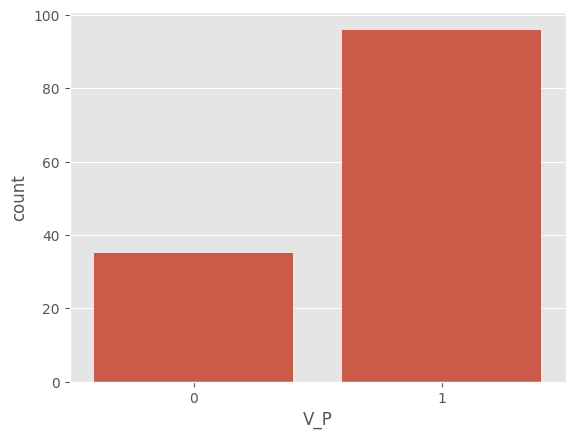

In [14]:
sns.countplot(x ='V_P', data = df)

<Axes: xlabel='R_A', ylabel='count'>

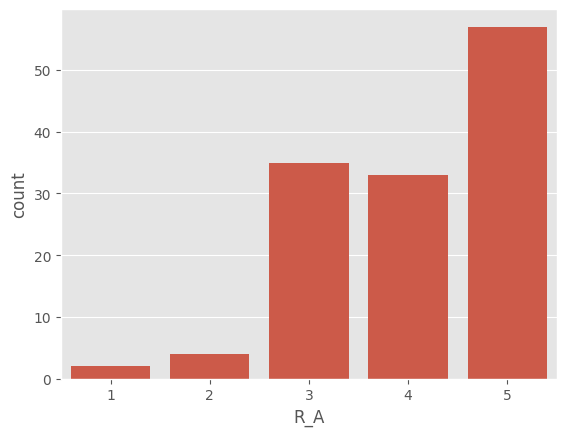

In [15]:
sns.countplot(x ='R_A', data = df)

<Axes: xlabel='C_S', ylabel='count'>

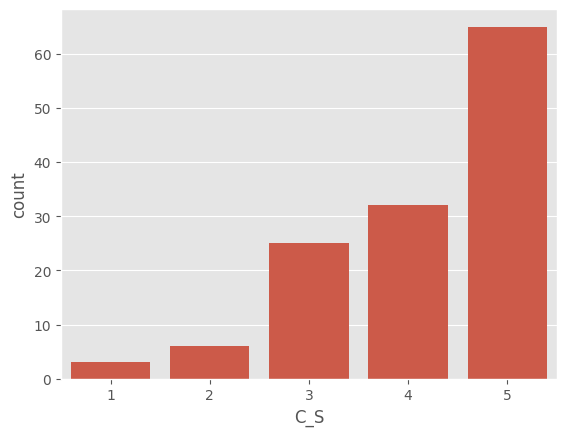

In [16]:
sns.countplot(x ='C_S', data = df)

<Axes: xlabel='B_I', ylabel='count'>

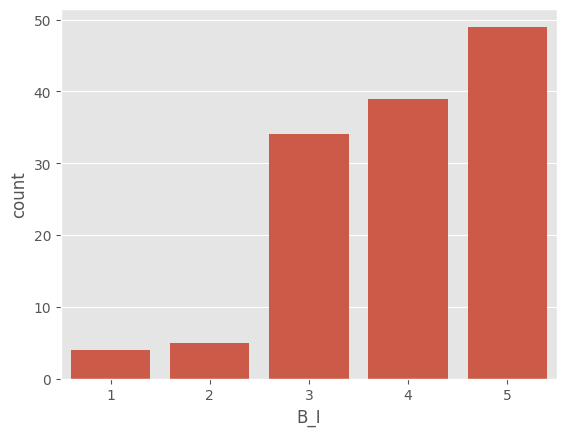

In [17]:
sns.countplot(x ='B_I', data = df)

<Axes: xlabel='C_T', ylabel='count'>

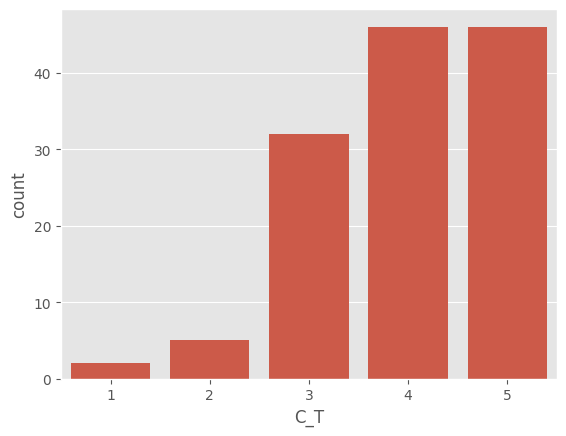

In [18]:
sns.countplot(x ='C_T', data = df)

<Axes: xlabel='A_D', ylabel='count'>

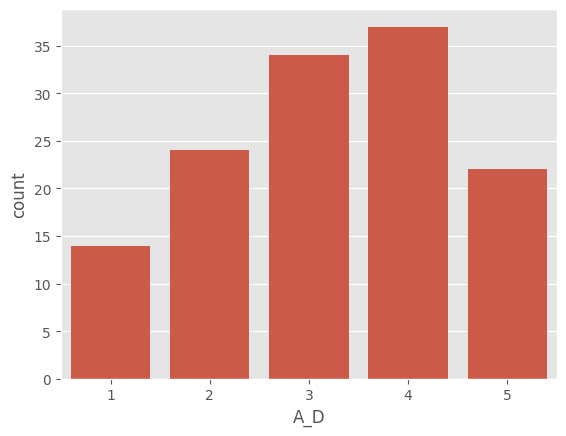

In [19]:
sns.countplot(x ='A_D', data = df)

<Axes: xlabel='V_C', ylabel='count'>

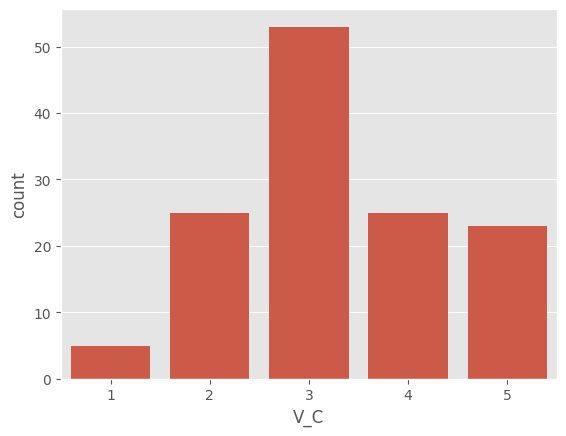

In [20]:
sns.countplot(x ='V_C', data = df)

## Ordinal Regression Models

In [21]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

In [22]:
mod_prob = OrderedModel(df['V_P'],
                        df[['R_A', 'C_S', 'B_I', 'C_T', 'A_D', 'V_C']],
                        distr='probit')

res_log1 = mod_prob.fit(method='bfgs')
res_log1.summary()

Optimization terminated successfully.
         Current function value: 0.473374
         Iterations: 23
         Function evaluations: 26
         Gradient evaluations: 26


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                    V_P   Log-Likelihood:                -62.012
Model:                   OrderedModel   AIC:                             138.0
Method:            Maximum Likelihood   BIC:                             158.2
Date:                Thu, 02 Apr 2026                                         
Time:                        16:50:23                                         
No. Observations:                 131                                         
Df Residuals:                     124                                         
Df Model:                           6                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
R_A            0.3024      0.187      1.616      0.106      -0.064       0.669
C_S           -0.1117      0.160     -0.696      0.486      -0.426       0.203
B_I           -0.0239      0.175     -0.136      0.892      -0.368       0.320
C_T            0.1366      0.164      0.831      0.406      -0.186       0.459
A_D           -0.5502      0.158     -3.491      0.000      -0.859      -0.241
V_C            0.4328      0.172      2.510      0.012       0.095       0.771
0/1            0.0907      0.818      0.111      0.912      -1.513       1.694
==============================================================================
"""

In [23]:
test = OrderedModel(df['V_P'], df[['R_A', 'C_S', 'B_I', 'C_T', 'A_D', 'V_C']], distr="probit")
res_log = test.fit(method='bfgs')
print(res_log.summary())

test = OrderedModel(df['V_P'], df[['R_A', 'C_S', 'B_I', 'C_T', 'A_D', 'V_C']], distr="logit")
res_log = test.fit(method='bfgs')
print(res_log.summary())

Optimization terminated successfully.
         Current function value: 0.473374
         Iterations: 23
         Function evaluations: 26
         Gradient evaluations: 26
                             OrderedModel Results                             
Dep. Variable:                    V_P   Log-Likelihood:                -62.012
Model:                   OrderedModel   AIC:                             138.0
Method:            Maximum Likelihood   BIC:                             158.2
Date:                Thu, 02 Apr 2026                                         
Time:                        16:50:30                                         
No. Observations:                 131                                         
Df Residuals:                     124                                         
Df Model:                           6                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

In [24]:
mod_prob = OrderedModel(df['V_P'],
                        df[['R_A', 'C_S', 'B_I', 'C_T', 'A_D', 'V_C']],
                        distr='logit')

res_log = mod_prob.fit(method='bfgs')
res_log.summary()

Optimization terminated successfully.
         Current function value: 0.474884
         Iterations: 32
         Function evaluations: 35
         Gradient evaluations: 35


<class 'statsmodels.iolib.summary.Summary'>
"""
                             OrderedModel Results                             
==============================================================================
Dep. Variable:                    V_P   Log-Likelihood:                -62.210
Model:                   OrderedModel   AIC:                             138.4
Method:            Maximum Likelihood   BIC:                             158.5
Date:                Thu, 02 Apr 2026                                         
Time:                        16:50:39                                         
No. Observations:                 131                                         
Df Residuals:                     124                                         
Df Model:                           6                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
R_A            0.5114      0.315      1.622      0.105      -0.107       1.129
C_S           -0.1710      0.269     -0.635      0.526      -0.699       0.357
B_I           -0.0208      0.295     -0.070      0.944      -0.600       0.558
C_T            0.1984      0.273      0.727      0.467      -0.337       0.733
A_D           -0.9147      0.272     -3.360      0.001      -1.448      -0.381
V_C            0.7633      0.294      2.599      0.009       0.188       1.339
0/1            0.3425      1.406      0.244      0.808      -2.413       3.099
==============================================================================
"""

## From the above two models (Logit and Probit) it is evident that: R_A,A_D & V_C have significant features.
Range Anxiety, Autonomous Driving, Vehicle Connection: We assume that features (input variables are continuous) and the target variables are categorical. (P<0.05).Statistically significant: If the p-value is lower than a pre-defined number, which is generally taken as 0.05, the null hypothesis is rejected and we claim that the result is statistically significant and that the alternative hypothesis is true. On the other hand, if the result is not statistically significant, we do not reject the null hypothesis.

## There are different statistical tests that can be used for ordinal dependent variables and categorical one independent variable with two levels (yes or no). We have to work on Wilcoxon-Mann Whitney test.!

## H0: Two populations views are equal, H1: Two populations are not equal
## If p<0.05,  (There is a significant difference in the views of the respondents regarding the two questions. This means that there is a 1 in 20 chance that the result of the study is not true; or that if you conducted the trial 20 times, you could expect that there would be only 1 trial which showed a p value on a different side of 0.05, which means H0 is true)
## If p>0.05, (There is no significant difference in the views of the respondents regarding the two questions. There is a higher chance than 1 in 20 trials, the results of the testing of hypothesis of correlation would not give the same result.Thus, the data correlation is statistically insignificant.)


In [25]:
import scipy.stats as stats
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['R_A'], y=df['A_D'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(11869.5), pvalue=np.float64(2.8742226440472835e-08))

In [26]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['R_A'], y=df['V_C'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(12015.5), pvalue=np.float64(5.40811533491795e-09))

In [27]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['A_D'], y=df['V_C'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(8538.5), pvalue=np.float64(0.944302138016619))

In [28]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['R_A'], y=df['C_S'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(8044.0), pvalue=np.float64(0.34922226752532226))

In [29]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['R_A'], y=df['B_I'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(9073.0), pvalue=np.float64(0.3963642145462358))

In [30]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['R_A'], y=df['C_T'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(9027.0), pvalue=np.float64(0.44208166631286705))

In [31]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['C_S'], y=df['C_T'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(9609.0), pvalue=np.float64(0.07514121415464639))

In [32]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['C_S'], y=df['B_I'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(9617.5), pvalue=np.float64(0.07260420775161938))

In [33]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['V_P'], y=df['R_A'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(96.0), pvalue=np.float64(1.2257508916713608e-46))

In [34]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['V_P'], y=df['A_D'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(672.0), pvalue=np.float64(2.5604284411704035e-41))

In [35]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['V_P'], y=df['V_C'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(240.0), pvalue=np.float64(3.579360700539679e-45))

In [36]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['V_P'], y=df['C_S'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(144.0), pvalue=np.float64(2.2880690876691536e-46))

In [37]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['V_P'], y=df['B_I'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(192.0), pvalue=np.float64(1.1720634648663402e-45))

In [38]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['V_P'], y=df['C_T'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(96.0), pvalue=np.float64(1.5348119081353426e-46))

In [39]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['A_D'], y=df['C_S'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(4913.0), pvalue=np.float64(5.872298844591883e-10))

In [40]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['A_D'], y=df['B_I'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(5723.5), pvalue=np.float64(1.4871061181412418e-06))

In [41]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['A_D'], y=df['C_T'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(5574.0), pvalue=np.float64(3.8953786146250593e-07))

In [42]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['V_C'], y=df['C_S'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(4812.5), pvalue=np.float64(1.6404593841870493e-10))

In [43]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['V_C'], y=df['B_I'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(5562.5), pvalue=np.float64(3.193880776990599e-07))

In [44]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['V_C'], y=df['C_T'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(5370.5), pvalue=np.float64(5.391190325624123e-08))

In [45]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['V_C'], y=df['R_A'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(5145.5), pvalue=np.float64(5.40811533491795e-09))

In [46]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['V_C'], y=df['A_D'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(8622.5), pvalue=np.float64(0.944302138016619))

In [47]:
# perform two-sided test. You can use 'greater' or 'less' for one-sided test
stats.mannwhitneyu(x=df['A_D'], y=df['R_A'], alternative = 'two-sided')

MannwhitneyuResult(statistic=np.float64(5291.5), pvalue=np.float64(2.8742226440472835e-08))

In [48]:

from tabulate import tabulate
data= [["R_A & A_D",2.8742226440472835e-08 ],
       ["R_A & V_C", 5.40811533491795e-09],
       ["A_D & V_C", 0.944302138016619],
       ["R_A & C_S", 0.34922226752532226],
       ["R_A & B_I", 0.3963642145462358],
       ["R_A & C_T", 0.44208166631286705],
       ["A_D & C_S", 5.872298844591883e-10],
       ["A_D & B_I", 1.4871061181412418e-06],
       ["A_D & C_T", 3.8953786146250593e-07],
       ["V_C & C_S", 1.6404593841870493e-10],
       ["V_C & B_I", 3.193880776990599e-07],
       ["V_C & C_T", 5.391190325624123e-08],
       ["V_C & R_A", 5.40811533491795e-09],
       ["V_C & A_D", 0.944302138016619],
       ["A_D & R_A", 2.8742226440472835e-08]]

#display table
print(tabulate(data, headers=["Dependent Factors Chosen", "P Values"]))


Dependent Factors Chosen       P Values
--------------------------  -----------
R_A & A_D                   2.87422e-08
R_A & V_C                   5.40812e-09
A_D & V_C                   0.944302
R_A & C_S                   0.349222
R_A & B_I                   0.396364
R_A & C_T                   0.442082
A_D & C_S                   5.8723e-10
A_D & B_I                   1.48711e-06
A_D & C_T                   3.89538e-07
V_C & C_S                   1.64046e-10
V_C & B_I                   3.19388e-07
V_C & C_T                   5.39119e-08
V_C & R_A                   5.40812e-09
V_C & A_D                   0.944302
A_D & R_A                   2.87422e-08
